### Overview

Google Earth Engine (GEE) is a cloud-based platform that has a large public data catalog and computing infrastructure. The [XEE](https://github.com/google/Xee) extension makes it possible to obtain pre-processed data cube directly from GEE as a XArray Dataset. In this section, we will learn how to process the GEE data using XArray and Dask on local compute infrastructure using the time-series processing capabilities of XArray.


*Note: You must have a Google Earth Engine account to complete this section. If you do not have one, [follow our guide](https://courses.spatialthoughts.com/gee-sign-up.html) to sign up.*

### Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install xee rioxarray dask['distributed'] xvec exactextract

In [ ]:
import datetime
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pyproj
import rioxarray as rxr
import xarray as xr
from xee import helpers
import xvec
import exactextract


In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

### Initialize EE and Dask Cluster

Initialize EE with the [High-Volume EndPoint](https://developers.google.com/earth-engine/guides/processing_environments#high-volume_endpoint) which is recommended to be used with XEE for workflows that do not use a lot of server side processing and are primarily for extracting data from stored collections. Replace the value of the `cloud_project` variable with your own project id that is linked with GEE.


In [ ]:
cloud_project = 'spatialthoughts' # replace with your project id

try:
    ee.Initialize(
        project=cloud_project,
        opt_url='https://earthengine-highvolume.googleapis.com')
except:
    ee.Authenticate()
    ee.Initialize(
        project=cloud_project,
        opt_url='https://earthengine-highvolume.googleapis.com')

Setup a local Dask cluster.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


Each of our Dask workers need Earth Engine authentication. Initialize Dask workers using `ee.Initialize()`.

In [ ]:
from dask.distributed import WorkerPlugin

class EEPlugin(WorkerPlugin):
    def __init__(self):
        pass
    def setup(self, worker):
        self.worker = worker
        try:
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')
        except:
            ee.Authenticate()
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')

ee_plugin = EEPlugin()
client.register_plugin(ee_plugin)


### Load Area of Interest


In [ ]:
aoi_file_path = 'https://storage.googleapis.com/spatialthoughts-public-data/' \
  'bangalore.geojson'
aoi_gdf = gpd.read_file(aoi_file_path)
aoi_gdf

In [ ]:
geometry = aoi_gdf.geometry.union_all()
geometry

### Load Data from GEE

We will load the [VIIRS Nighttime Day/Night Annual Band Composites V2.1](https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_ANNUAL_V21) dataset.

Configure the time period and variables. Note that this dataset is available. form 2012 upto 2021.

In [ ]:
start_year = 2016
end_year = 2021
variable = 'average'

Define the ImageCollection and apply filters using the Earth Engine Python API syntax.

In [ ]:
start_date = ee.Date.fromYMD(start_year, 1, 1)
end_date = ee.Date.fromYMD(end_year + 1, 1, 1)

ntlCol = ee.ImageCollection('NOAA/VIIRS/DNB/ANNUAL_V21')

filtered = ntlCol \
  .filter(ee.Filter.date(start_date, end_date)) \
  .select(variable)

We now read the filtered collecting using XEE. XEE requires explicit grid parameters. We extract these using the helper function [`extract_grid_params`](hhttps://xee.readthedocs.io/en/latest/_autosummary/xee.extract_grid_params.html#xee.extract_grid_params).

In [ ]:
grid_params = helpers.extract_grid_params(filtered)
grid_params

Open the ImageCollection as an XArray Dataset.

In [ ]:
ds = xr.open_dataset(
    filtered,
    engine='ee',
    **grid_params,
    chunks={} # Enable dask
)
ds

Select the variable. Many XArray functions require all the dimensions to be sorted in ascending order. Make sure y and x are sorted.

In [ ]:
da = ds.average
da = da.sortby(['y', 'x'])

Clip the raster to the bounds of the zones.



In [ ]:
bounds = aoi_gdf.total_bounds  # (minx, miny, maxx, maxy)
da_clipped = da.rio.clip_box(*bounds)
da_clipped

We now call `.compute()` to load the data. Each worker in the Dask cluster will fetch the required pixels from Google Earth Engine in parallel and construct the output array.

In [ ]:
%%time
da_clipped = da_clipped.compute()

### Visualizing the Data

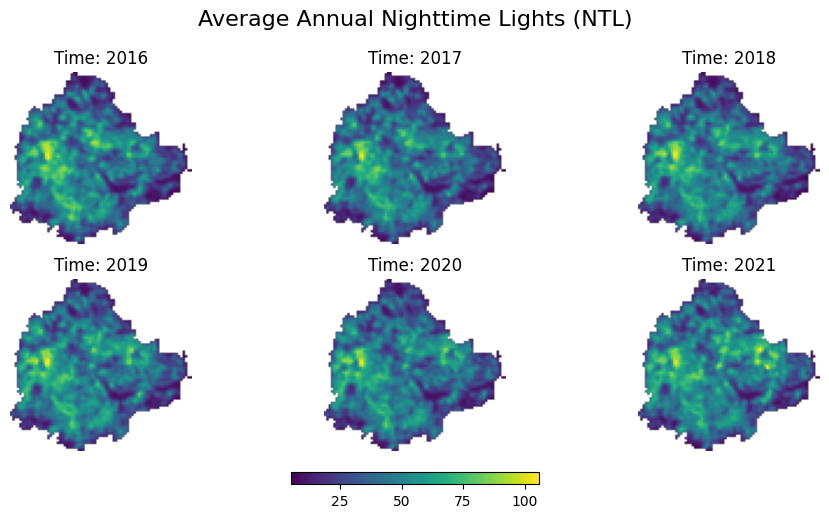

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3)
fig.set_size_inches(10,5)
fig.suptitle('Average Annual Nighttime Lights (NTL)', fontsize=16)

# clip to the aoi geometry
da_clipped = da_clipped.rio.clip(aoi_gdf.geometry)

for i, ax in enumerate(axes.flat):
    # Check if we have enough time slices to plot
    if i < da_clipped.sizes['time']:
        time_slice = da_clipped.isel(time=i)
        # Using imshow to visualize the 2D data for each timestep
        # Pass the numpy array values to imshow
        im = ax.imshow(time_slice.values, cmap='viridis', origin='lower')
        ax.set_title(f'Time: {time_slice.time.dt.year.item()}')
        ax.set_axis_off()
    else:
        # Hide any unused subplots
        fig.delaxes(ax)

plt.tight_layout()

cbar_kwargs = {
    'orientation':'horizontal',
    'fraction': 0.03,
    'pad': 0.05,
    'extend':'neither',
}
plt.colorbar(im, ax=axes.ravel().tolist(), **cbar_kwargs)
plt.show()

### Compute Aggregated Time-Series

We will now use the [`xvec.zonal_stats()`](https://xvec.readthedocs.io/en/stable/zonal_stats.html) method to aggregates raster pixel values within each polygon.


In [ ]:
aggregated = da_clipped.xvec.zonal_stats(
    aoi_gdf.geometry,
    x_coords='x',
    y_coords='y',
    stats=['mean'],
    method='exactextract'
)

The input DataArray has a `time` dimension which will be kept intact and we will get a time-series of spatially aggregated values.

In [ ]:
aggregated

At this point we only have the geometries from the original vector data. It will be useful to add some attribues from the original GeoDataFrame. As we have am XArray vector data cube, this is done by adding it as a coordinate variable. The cell below adds the `NAME` attribute with the county name.

In [ ]:
aggregated['name'] = ('geometry', aoi_gdf['name'].values)
aggregated = aggregated.assign_coords({'name': aggregated['name']})
aggregated

Convert the XArray Dataset back to a GeoDataFrame for tabular manipulation and export.

In [ ]:
aggregated_gdf = aggregated.xvec.to_geodataframe(name='ntl_mean', geometry='geometry')
aggregated_gdf

 Reset the index to convert the multi-index into columns, and select and rename columns to prepare the output.


In [ ]:
output_gdf = aggregated_gdf.reset_index()
output_gdf = output_gdf[['name', 'time', 'ntl_mean', 'geometry']]
output_gdf

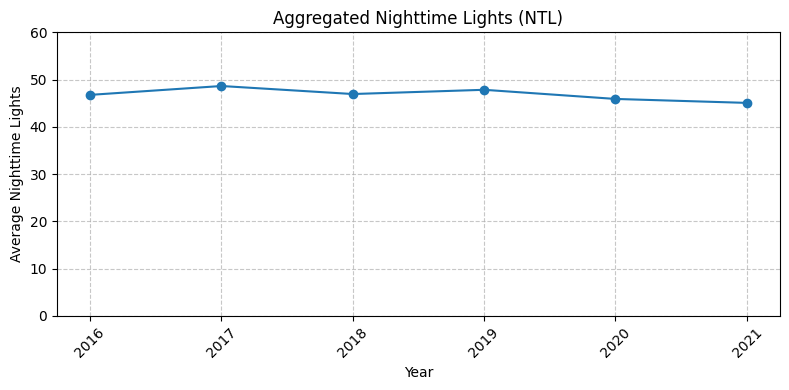

In [30]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(8, 4))
plt.plot(output_gdf['time'], output_gdf['ntl_mean'], marker='o')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Average Nighttime Lights')
plt.title('Aggregated Nighttime Lights (NTL)')

# Set y-axis to start from 0
plt.ylim(ymin=0, ymax=60)

# Improve date formatting on x-axis
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exercise

The [GEE Community Catalog](https://gee-community-catalog.org/) is a large collection of community curated datasets hosted on Earth Engine. The XEE extension works equally well on these datasets.

Access the [Global Annual Simulated NPP-VIIRS Nighttime Light Dataset (1992-2023)](https://gee-community-catalog.org/projects/srunet_npp_viirs_ntl/) dataset and plot a time-series of average nighttime lights for your region of interest.